# Baseline Classification by BSR Group

This notebook trains baseline **classification** models **per BSR group** (`main_bsr_group`) to predict:
- **TARGET**: `has_main_bsr` - Binary classification: Does product have a main BSR rank? (0=No, 1=Yes)

For each BSR group (with at least 100 products), we train:
1. **Logistic Regression** (L2 Regularized) - Linear classifier
2. **XGBoost Classifier** - Gradient boosting
3. **Random Forest Classifier** - Ensemble tree-based

With two feature sets:
1. **Top Features**: Top-ranked features from classification EDA
2. **All Features**: All available image features

**Note**: Classification predicts BSR presence within product categories.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, average_precision_score)
from xgboost import XGBClassifier
from tqdm.auto import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Color scheme for binary classification
CLASS_0_COLOR = '#E74C3C'      # Red for No BSR (class 0)
CLASS_1_COLOR = '#27AE60'      # Green for Has BSR (class 1)
MODEL_COLORS = {'LogisticRegression': '#3498DB', 'XGBoost': '#E67E22', 'RandomForest': '#9B59B6'}

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [11]:
# =============================================================================
# 1. DATA LOADING
# =============================================================================

DATA_PATH = "../../data/products_with_image_feats.csv"
df = pd.read_csv(DATA_PATH)

# Create binary classification targets
df['has_main_bsr'] = df['main_bsr_rank'].notna().astype(int)
df['has_lowest_bsr'] = df['lowest_bsr_rank'].notna().astype(int)

# Filter to products with image features
df = df[df['num_images'].notna()].copy()

print(f"Dataset shape: {df.shape}")
print(f"\nTarget Distribution:")
print(f"has_main_bsr:   Class 0: {(df['has_main_bsr']==0).sum():,} | Class 1: {(df['has_main_bsr']==1).sum():,}")

# Check main_bsr_group distribution (for products WITH BSR)
has_bsr_df = df[df['has_main_bsr'] == 1]
print(f"\nUnique main_bsr_groups (products with BSR): {has_bsr_df['main_bsr_group'].nunique()}")
print(f"\nMain BSR Group distribution (top 30):")
bsr_group_counts = has_bsr_df['main_bsr_group'].value_counts()
print(bsr_group_counts.head(30))

# For classification by group, we'll analyze how features differ between
# products WITH and WITHOUT BSR within categories
MIN_PRODUCTS_PER_GROUP = 300
valid_groups = bsr_group_counts[bsr_group_counts >= MIN_PRODUCTS_PER_GROUP].index.tolist()
print(f"\nGroups with >= {MIN_PRODUCTS_PER_GROUP} products: {len(valid_groups)}")

Dataset shape: (36879, 7654)

Target Distribution:
has_main_bsr:   Class 0: 11,113 | Class 1: 25,766

Unique main_bsr_groups (products with BSR): 142

Main BSR Group distribution (top 30):
main_bsr_group
Home & Kitchen                  3771
Health & Household              3669
Office Products                 3420
Baby                            2902
Clothing, Shoes & Jewelry       2140
Kitchen & Dining                1729
Electronics                     1641
Cell Phones & Accessories        816
Tools & Home Improvement         557
Video Games                      524
Pet Supplies                     490
Sports & Outdoors                433
Industrial & Scientific          397
Musical Instruments              317
Beauty & Personal Care           228
Laptop Backpacks                 227
USB Hubs                         212
Computer Mice                    196
Computers & Accessories          191
Webcams                          187
Automotive                       155
Computer Monitor St

In [12]:
# =============================================================================
# 2. DEFINE FEATURE SETS
# =============================================================================

# Columns to EXCLUDE - metadata, identifiers, and POST-LISTING metrics
EXCLUDE_COLS = [
    # Identifiers and metadata
    'Unnamed: 0.1', 'Unnamed: 0', 'asin', 'category', 'query', 'page',
    'source_section', 'type', 'title', 'image', 'url', 'optimized_url',
    'delivery', 'price_string', 'price_symbol', 'colors', 'location',
    'search_message', 'sd_feature_bullets_text', 'sd_title', 'sd_parent_asin',
    'sd_price_symbol', 'sd_availability_status', 'sd_product_category',
    'sd_category_id', 'sd_ratings_distribution', 'sd_customer_sentiments',
    'sd_error', 'sd_errors', 'sd_best_sellers_rank', 'certification', 'coupon_text',
    'fetched_at_unix',
    
    # BSR-related columns - CRITICAL: exclude to prevent leakage
    'main_bsr_group', 'main_bsr_rank', 'lowest_bsr_group', 'lowest_bsr_rank',
    'has_main_bsr', 'has_lowest_bsr',  # Binary targets
    'target',  # Dynamic target column created per group
    
    # POST-LISTING METRICS - Not available for new products!
    'stars', 'total_reviews', 'sd_average_rating', 'sd_total_reviews',
    'sd_stars', 'sd_ratings_count',
    'sd_rating_pct_1', 'sd_rating_pct_2', 'sd_rating_pct_3', 'sd_rating_pct_4', 'sd_rating_pct_5',
    'sd_sent_count_POSITIVE', 'sd_sent_count_MIXED', 'sd_sent_count_NEGATIVE',
    'organic_position', 'absolute_position',
    'number_of_people_bought', 'sd_number_bought_past_month',
    'is_best_seller', 'is_amazon_choice',
    'limited_time_deal', 'deal_of_the_day', 'sponsored',
    'availability_quantity', 'sd_is_frequently_returned',
    'sd_previous_price'
]

# Get all numeric columns that are image features
all_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
all_feature_cols = [c for c in all_numeric_cols if c not in EXCLUDE_COLS]

# Top 20 features from Classification EDA (based on Point-Biserial correlation,
# Cohen's d effect size, and Mutual Information)
TOP_FEATURES_FROM_EDA = [
    'cnn_pca_0003',                    # score: 1.0000 - best predictor
    'clip_pca_0005',                   # score: 0.8475
    'clip_pca_0002',                   # score: 0.8452
    'clip_pca_0000',                   # score: 0.8081
    'cnn_pca_0000',                    # score: 0.6816
    'clip_pca_0003',                   # score: 0.5769
    'clip_pca_0001',                   # score: 0.3963
    'det_conf_mean_mean',              # score: 0.3859
    'det_conf_max_mean',               # score: 0.3760
    'det_has_person_mean',             # score: 0.3423
    'brightness_std_mean',             # score: 0.3223
    'contrast_mean',                   # score: 0.3222
    'aspect_ratio_mean',               # score: 0.2949
    'det_main_box_center_dist_mean',   # score: 0.2917
    'cnn_pca_0009',                    # score: 0.2878
    'cnn_pca_0001',                    # score: 0.2872
    'clip_pca_0009',                   # score: 0.2630
    'cnn_pca_0002',                    # score: 0.2596
    'exposure_clipped_high_pct_mean',  # score: 0.2525
    'border_clutter_score_mean',       # score: 0.2394
]

# Filter to only those present in dataset
top_features = [f for f in TOP_FEATURES_FROM_EDA if f in df.columns]

print(f"Total available features: {len(all_feature_cols)}")
print(f"Top features from classification EDA: {len(top_features)}")
print(f"\nTop features:")
for i, f in enumerate(top_features, 1):
    print(f"  {i:2}. {f}")

Total available features: 7585
Top features from classification EDA: 20

Top features:
   1. cnn_pca_0003
   2. clip_pca_0005
   3. clip_pca_0002
   4. clip_pca_0000
   5. cnn_pca_0000
   6. clip_pca_0003
   7. clip_pca_0001
   8. det_conf_mean_mean
   9. det_conf_max_mean
  10. det_has_person_mean
  11. brightness_std_mean
  12. contrast_mean
  13. aspect_ratio_mean
  14. det_main_box_center_dist_mean
  15. cnn_pca_0009
  16. cnn_pca_0001
  17. clip_pca_0009
  18. cnn_pca_0002
  19. exposure_clipped_high_pct_mean
  20. border_clutter_score_mean


In [13]:
# =============================================================================
# 3. HELPER FUNCTIONS
# =============================================================================

def prepare_data(df_subset, target_col, feature_cols, test_size=0.2, random_state=42, verbose=False):
    """
    Prepare data for binary classification.
    Returns None if insufficient data.
    """
    if len(df_subset) < 50:  # Minimum samples threshold
        return None
    
    # Get features that exist in dataset
    valid_features = [f for f in feature_cols if f in df_subset.columns]
    
    # Prepare X and y
    X = df_subset[valid_features].copy()
    y = df_subset[target_col].values  # Binary target (0/1)
    
    # Replace infinite values with NaN
    X = X.replace([np.inf, -np.inf], np.nan)
    
    # Remove columns with >50% missing values
    missing_pct = X.isnull().sum() / len(X)
    cols_to_keep = missing_pct[missing_pct < 0.5].index.tolist()
    X = X[cols_to_keep]
    valid_features = cols_to_keep
    
    if len(valid_features) == 0:
        return None
    
    # Impute remaining missing values with median
    for col in X.columns:
        median_val = X[col].median()
        if pd.isna(median_val):
            median_val = 0
        X[col] = X[col].fillna(median_val)
    
    # Drop any remaining rows with NaN
    valid_idx = ~X.isnull().any(axis=1)
    X = X[valid_idx]
    y = y[valid_idx]
    
    if len(X) < 50:
        return None
    
    # Check class balance - need both classes
    if len(np.unique(y)) < 2:
        return None
    
    # Stratified split to maintain class balance
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
    except:
        # Fall back to non-stratified if stratification fails
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return {
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train,
        'y_test': y_test,
        'feature_names': valid_features,
        'scaler': scaler,
        'n_samples': len(X),
        'class_balance': sum(y) / len(y)  # Proportion of positive class
    }

def get_classification_models(fast_mode=False):
    """
    Return dictionary of classification models.
    fast_mode=True: Faster settings for high-dimensional data
    """
    if fast_mode:
        n_est = 50
        max_depth = 10
    else:
        n_est = 100
        max_depth = 10
    
    models = {
        'LogisticRegression': LogisticRegression(
            penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42
        ),
        'XGBoost': XGBClassifier(
            n_estimators=n_est,
            max_depth=5,
            learning_rate=0.1,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42
        ),
        'RandomForest': RandomForestClassifier(
            n_estimators=n_est,
            max_depth=max_depth,
            random_state=42,
            n_jobs=-1
        )
    }
    
    return models

def evaluate_classifier(model, X_train, X_test, y_train, y_test):
    """
    Evaluate classification model and return metrics.
    """
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Probability predictions (for ROC-AUC)
    if hasattr(model, 'predict_proba'):
        y_train_proba = model.predict_proba(X_train)[:, 1]
        y_test_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_train_proba = model.decision_function(X_train)
        y_test_proba = model.decision_function(X_test)
    
    # Metrics
    metrics = {
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'train_f1': f1_score(y_train, y_train_pred),
        'test_f1': f1_score(y_test, y_test_pred),
        'train_roc_auc': roc_auc_score(y_train, y_train_proba),
        'test_roc_auc': roc_auc_score(y_test, y_test_proba),
        'test_precision': precision_score(y_test, y_test_pred),
        'test_recall': recall_score(y_test, y_test_pred)
    }
    return metrics

print("Helper functions defined.")

Helper functions defined.


In [14]:
# =============================================================================
# 4. CROSS-VALIDATION SETUP
# =============================================================================

CV_FOLDS = 5
CV_FOLDS_FAST = 3
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
skf_fast = StratifiedKFold(n_splits=CV_FOLDS_FAST, shuffle=True, random_state=42)

print(f"CV setup: {CV_FOLDS}-fold stratified for Top Features, {CV_FOLDS_FAST}-fold for All Features")

CV setup: 5-fold stratified for Top Features, 3-fold for All Features


In [15]:
# =============================================================================
# 5. TRAIN MODELS FOR EACH CATEGORY
# =============================================================================

def train_models_for_category(df_cat, category_name, target_col, feature_cols, 
                               feature_set_name, use_fast_mode=False):
    """
    Train all classification models for a specific category and feature set.
    Returns a dictionary with all results.
    """
    results = {}
    
    # Prepare data
    data = prepare_data(df_cat, target_col, feature_cols)
    if data is None:
        return None
    
    cv = skf_fast if use_fast_mode else skf
    
    # Train classification models
    for name, model in get_classification_models(fast_mode=use_fast_mode).items():
        try:
            # Cross-validation with ROC-AUC
            cv_scores = cross_val_score(model, data['X_train'], data['y_train'], 
                                       cv=cv, scoring='roc_auc')
            model.fit(data['X_train'], data['y_train'])
            
            # Evaluate
            metrics = evaluate_classifier(model, data['X_train'], data['X_test'],
                                         data['y_train'], data['y_test'])
            
            results[name] = {
                'cv_roc_auc_mean': cv_scores.mean(),
                'cv_roc_auc_std': cv_scores.std(),
                'train_accuracy': metrics['train_accuracy'],
                'test_accuracy': metrics['test_accuracy'],
                'train_f1': metrics['train_f1'],
                'test_f1': metrics['test_f1'],
                'train_roc_auc': metrics['train_roc_auc'],
                'test_roc_auc': metrics['test_roc_auc'],
                'test_precision': metrics['test_precision'],
                'test_recall': metrics['test_recall'],
                'model': model
            }
        except Exception as e:
            pass
    
    return {
        'results': results,
        'data': data,
        'n_samples': data['n_samples'],
        'n_features': len(data['feature_names']),
        'class_balance': data.get('class_balance', None)
    }

print("Training function defined.")

Training function defined.


In [16]:
# =============================================================================
# 6. RUN TRAINING FOR ALL BSR GROUPS
# =============================================================================

# Use valid_groups (main_bsr_group with at least MIN_PRODUCTS_PER_GROUP products)
groups = valid_groups
print(f"Training classification models for {len(groups)} BSR groups (with >= {MIN_PRODUCTS_PER_GROUP} products)...")
print(f"\nGroups:")
for g in groups:
    print(f"  - {g}: {bsr_group_counts[g]} products with BSR")

# Storage for all results
all_results = {
    'has_main_bsr': {'top': {}, 'all': {}}
}

Training classification models for 14 BSR groups (with >= 300 products)...

Groups:
  - Home & Kitchen: 3771 products with BSR
  - Health & Household: 3669 products with BSR
  - Office Products: 3420 products with BSR
  - Baby: 2902 products with BSR
  - Clothing, Shoes & Jewelry: 2140 products with BSR
  - Kitchen & Dining: 1729 products with BSR
  - Electronics: 1641 products with BSR
  - Cell Phones & Accessories: 816 products with BSR
  - Tools & Home Improvement: 557 products with BSR
  - Video Games: 524 products with BSR
  - Pet Supplies: 490 products with BSR
  - Sports & Outdoors: 433 products with BSR
  - Industrial & Scientific: 397 products with BSR
  - Musical Instruments: 317 products with BSR


In [17]:
# =============================================================================
# 7. TRAIN CLASSIFICATION MODELS (TOP FEATURES) - Per BSR Group
# =============================================================================

print("="*80)
print("has_main_bsr CLASSIFICATION - TOP FEATURES (Per BSR Group)")
print("="*80)

# Get products without any BSR (class 0 pool)
df_no_bsr = df[df['has_main_bsr'] == 0].copy()
print(f"Products without BSR (class 0 pool): {len(df_no_bsr)}")

for group in tqdm(groups, desc='BSR Groups (Top Features)'):
    # For each BSR group:
    # - Class 1: Products that have BSR in this specific group
    # - Class 0: Products without any BSR
    df_has_bsr_group = df[df['main_bsr_group'] == group].copy()
    df_has_bsr_group['target'] = 1
    
    # Sample from no-BSR pool to balance classes (or use all if smaller)
    n_positive = len(df_has_bsr_group)
    df_no_bsr_sample = df_no_bsr.sample(n=min(n_positive, len(df_no_bsr)), random_state=42).copy()
    df_no_bsr_sample['target'] = 0
    
    # Combine for this group's dataset
    df_group = pd.concat([df_has_bsr_group, df_no_bsr_sample], ignore_index=True)
    
    result = train_models_for_category(
        df_group, group, 'target', top_features, 'top', use_fast_mode=False
    )
    if result is not None:
        all_results['has_main_bsr']['top'][group] = result
        best_model = max(result['results'].keys(), key=lambda k: result['results'][k]['test_roc_auc'])
        best_roc = result['results'][best_model]['test_roc_auc']
        print(f"  {group[:50]}: n={result['n_samples']}, Best={best_model} (ROC-AUC={best_roc:.4f})")
    else:
        print(f"  {group[:50]}: Insufficient data")

has_main_bsr CLASSIFICATION - TOP FEATURES (Per BSR Group)
Products without BSR (class 0 pool): 11113


BSR Groups (Top Features):   7%|▋         | 1/14 [00:02<00:28,  2.16s/it]

  Home & Kitchen: n=7542, Best=XGBoost (ROC-AUC=0.9573)


BSR Groups (Top Features):  14%|█▍        | 2/14 [00:04<00:25,  2.11s/it]

  Health & Household: n=7338, Best=XGBoost (ROC-AUC=0.9684)


...

  Sports & Outdoors: n=866, Best=RandomForest (ROC-AUC=0.9273)


BSR Groups (Top Features):  93%|█████████▎| 13/14 [00:22<00:01,  1.37s/it]

  Industrial & Scientific: n=794, Best=RandomForest (ROC-AUC=0.9464)


BSR Groups (Top Features): 100%|██████████| 14/14 [00:23<00:00,  1.67s/it]

  Musical Instruments: n=634, Best=LogisticRegression (ROC-AUC=0.9861)


In [18]:
# =============================================================================
# 8. TRAIN CLASSIFICATION MODELS (ALL FEATURES) - Per BSR Group
# =============================================================================

print("="*80)
print("has_main_bsr CLASSIFICATION - ALL FEATURES (Per BSR Group)")
print("="*80)

for group in tqdm(groups, desc='BSR Groups (All Features)'):
    # For each BSR group:
    # - Class 1: Products that have BSR in this specific group
    # - Class 0: Products without any BSR
    df_has_bsr_group = df[df['main_bsr_group'] == group].copy()
    df_has_bsr_group['target'] = 1
    
    # Sample from no-BSR pool to balance classes (or use all if smaller)
    n_positive = len(df_has_bsr_group)
    df_no_bsr_sample = df_no_bsr.sample(n=min(n_positive, len(df_no_bsr)), random_state=42).copy()
    df_no_bsr_sample['target'] = 0
    
    # Combine for this group's dataset
    df_group = pd.concat([df_has_bsr_group, df_no_bsr_sample], ignore_index=True)
    
    result = train_models_for_category(
        df_group, group, 'target', all_feature_cols, 'all', use_fast_mode=True
    )
    if result is not None:
        all_results['has_main_bsr']['all'][group] = result
        best_model = max(result['results'].keys(), key=lambda k: result['results'][k]['test_roc_auc'])
        best_roc = result['results'][best_model]['test_roc_auc']
        print(f"  {group[:50]}: n={result['n_samples']}, feats={result['n_features']}, Best={best_model} (ROC-AUC={best_roc:.4f})")
    else:
        print(f"  {group[:50]}: Insufficient data")

has_main_bsr CLASSIFICATION - ALL FEATURES (Per BSR Group)


BSR Groups (All Features):   7%|▋         | 1/14 [00:43<09:30, 43.89s/it]

  Home & Kitchen: n=7542, feats=7581, Best=XGBoost (ROC-AUC=0.9625)


BSR Groups (All Features):  14%|█▍        | 2/14 [01:50<11:30, 57.52s/it]

  Health & Household: n=7338, feats=7581, Best=XGBoost (ROC-AUC=0.9736)


...

  Sports & Outdoors: n=866, feats=7581, Best=XGBoost (ROC-AUC=0.9370)


BSR Groups (All Features):  93%|█████████▎| 13/14 [07:41<00:22, 22.69s/it]

  Industrial & Scientific: n=794, feats=7581, Best=RandomForest (ROC-AUC=0.9709)


BSR Groups (All Features): 100%|██████████| 14/14 [07:55<00:00, 33.97s/it]

  Musical Instruments: n=634, feats=7581, Best=LogisticRegression (ROC-AUC=0.9990)


In [32]:
# =============================================================================
# 9. CLASSIFICATION RESULTS SUMMARY
# =============================================================================

# Note: For classification, we focus on has_main_bsr target
# The classification task is the same across all groups (predict BSR presence)
print("Classification models trained for has_main_bsr across all groups")
print(f"Groups processed (Top Features): {len(all_results['has_main_bsr']['top'])}")
print(f"Groups processed (All Features): {len(all_results['has_main_bsr']['all'])}")

Classification models trained for has_main_bsr across all groups
Groups processed (Top Features): 14
Groups processed (All Features): 14


In [33]:
# =============================================================================
# 10. PRINT OVERALL RESULTS
# =============================================================================

print("="*80)
print("CLASSIFICATION RESULTS BY GROUP")
print("="*80)

# Print results for top features
print("\nTop Features Results:")
for group, result in all_results['has_main_bsr']['top'].items():
    if result and result['results']:
        best_model = max(result['results'].keys(), key=lambda k: result['results'][k]['test_roc_auc'])
        best_metrics = result['results'][best_model]
        print(f"  {group[:40]}: ROC-AUC={best_metrics['test_roc_auc']:.4f}, Acc={best_metrics['test_accuracy']:.4f} ({best_model})")

CLASSIFICATION RESULTS BY GROUP

Top Features Results:
  Home & Kitchen: ROC-AUC=0.9573, Acc=0.9046 (XGBoost)
  Health & Household: ROC-AUC=0.9684, Acc=0.9339 (XGBoost)
  Office Products: ROC-AUC=0.9838, Acc=0.9547 (RandomForest)
  Baby: ROC-AUC=0.9568, Acc=0.8906 (XGBoost)
  Clothing, Shoes & Jewelry: ROC-AUC=0.8679, Acc=0.8131 (XGBoost)
  Kitchen & Dining: ROC-AUC=0.9654, Acc=0.9176 (XGBoost)
  Electronics: ROC-AUC=0.9873, Acc=0.9513 (XGBoost)
  Cell Phones & Accessories: ROC-AUC=0.9884, Acc=0.9633 (RandomForest)
  Tools & Home Improvement: ROC-AUC=0.9625, Acc=0.8789 (XGBoost)
  Video Games: ROC-AUC=0.9833, Acc=0.9714 (RandomForest)
  Pet Supplies: ROC-AUC=0.8976, Acc=0.8112 (RandomForest)
  Sports & Outdoors: ROC-AUC=0.9273, Acc=0.8678 (RandomForest)
  Industrial & Scientific: ROC-AUC=0.9464, Acc=0.8679 (RandomForest)
  Musical Instruments: ROC-AUC=0.9861, Acc=0.9685 (LogisticRegression)


In [34]:
# =============================================================================
# 11. CREATE SUMMARY DATAFRAMES
# =============================================================================

def create_summary_df(results_dict, target_name, feature_set_name):
    """Create a summary DataFrame from classification results"""
    rows = []
    for group, group_results in results_dict.items():
        for model_name, metrics in group_results['results'].items():
            rows.append({
                'BSR_Group': group,
                'Target': target_name,
                'Feature_Set': feature_set_name,
                'Model': model_name,
                'CV_ROC_AUC_Mean': metrics['cv_roc_auc_mean'],
                'CV_ROC_AUC_Std': metrics['cv_roc_auc_std'],
                'Train_Accuracy': metrics['train_accuracy'],
                'Test_Accuracy': metrics['test_accuracy'],
                'Train_F1': metrics['train_f1'],
                'Test_F1': metrics['test_f1'],
                'Train_ROC_AUC': metrics['train_roc_auc'],
                'Test_ROC_AUC': metrics['test_roc_auc'],
                'Test_Precision': metrics['test_precision'],
                'Test_Recall': metrics['test_recall'],
                'N_Samples': group_results['n_samples'],
                'N_Features': group_results['n_features'],
                'Class_Balance': group_results.get('class_balance', None)
            })
    return pd.DataFrame(rows)

# Create summary DataFrames
summary_top = create_summary_df(all_results['has_main_bsr']['top'], 'has_main_bsr', 'Top Features')
summary_all_feats = create_summary_df(all_results['has_main_bsr']['all'], 'has_main_bsr', 'All Features')

# Combine all
summary_all = pd.concat([summary_top, summary_all_feats], ignore_index=True)

print(f"Summary DataFrame shape: {summary_all.shape}")
print(f"\nColumns: {summary_all.columns.tolist()}")
print(f"\nUnique BSR Groups: {summary_all['BSR_Group'].nunique()}")

Summary DataFrame shape: (84, 17)

Columns: ['BSR_Group', 'Target', 'Feature_Set', 'Model', 'CV_ROC_AUC_Mean', 'CV_ROC_AUC_Std', 'Train_Accuracy', 'Test_Accuracy', 'Train_F1', 'Test_F1', 'Train_ROC_AUC', 'Test_ROC_AUC', 'Test_Precision', 'Test_Recall', 'N_Samples', 'N_Features', 'Class_Balance']

Unique BSR Groups: 14


In [35]:
# =============================================================================
# 12. BEST MODEL PER BSR GROUP
# =============================================================================

print("="*80)
print("BEST MODEL PER BSR GROUP - CLASSIFICATION")
print("="*80)

# Best model per BSR group (both feature sets) by ROC-AUC
best_per_group = summary_all.loc[summary_all.groupby(['BSR_Group', 'Feature_Set'])['Test_ROC_AUC'].idxmax()]

print("\nBest models by Test ROC-AUC per BSR Group:")
display_cols = ['BSR_Group', 'Feature_Set', 'Model', 'Test_ROC_AUC', 'Test_Accuracy', 'Test_F1', 'N_Samples']
print(best_per_group[display_cols].sort_values(['Feature_Set', 'Test_ROC_AUC'], ascending=[True, False]).to_string(index=False))

BEST MODEL PER BSR GROUP - CLASSIFICATION

Best models by Test ROC-AUC per BSR Group:
                BSR_Group  Feature_Set              Model  Test_ROC_AUC  Test_Accuracy  Test_F1  N_Samples
      Musical Instruments All Features LogisticRegression      0.999008       0.968504 0.969231        634
Cell Phones & Accessories All Features       RandomForest      0.995848       0.966361 0.966767       1632
          Office Products All Features LogisticRegression      0.991476       0.961257 0.961678       6840
              Video Games All Features LogisticRegression      0.990295       0.980952 0.981308       1048
         Kitchen & Dining All Features            XGBoost      0.985833       0.942197 0.942857       3458
              Electronics All Features LogisticRegression      0.982606       0.960426 0.961194       3282
                     Baby All Features            XGBoost      0.978079       0.921619 0.922421       5804
 Tools & Home Improvement All Features LogisticRegression 

In [36]:
# =============================================================================
# 13. TOP PERFORMING BSR GROUPS
# =============================================================================

print("="*80)
print("TOP PERFORMING BSR GROUPS (CLASSIFICATION)")
print("="*80)

# Get best ROC-AUC per BSR group (best across all models and feature sets)
best_roc_per_group = summary_all.groupby('BSR_Group')['Test_ROC_AUC'].max().sort_values(ascending=False)

print("\nBest Test ROC-AUC by BSR Group (ranked):")
for i, (group, roc) in enumerate(best_roc_per_group.items(), 1):
    n_samples = summary_all[summary_all['BSR_Group'] == group]['N_Samples'].iloc[0]
    print(f"  {i:2}. {group[:60]}: ROC-AUC={roc:.4f} (n={n_samples})")

TOP PERFORMING BSR GROUPS (CLASSIFICATION)

Best Test ROC-AUC by BSR Group (ranked):
   1. Musical Instruments: ROC-AUC=0.9990 (n=634)
   2. Cell Phones & Accessories: ROC-AUC=0.9958 (n=1632)
   3. Office Products: ROC-AUC=0.9915 (n=6840)
   4. Video Games: ROC-AUC=0.9903 (n=1048)
   5. Electronics: ROC-AUC=0.9873 (n=3282)
   6. Kitchen & Dining: ROC-AUC=0.9858 (n=3458)
   7. Baby: ROC-AUC=0.9781 (n=5804)
   8. Tools & Home Improvement: ROC-AUC=0.9764 (n=1114)
   9. Health & Household: ROC-AUC=0.9736 (n=7338)
  10. Industrial & Scientific: ROC-AUC=0.9709 (n=794)
  11. Home & Kitchen: ROC-AUC=0.9625 (n=7542)
  12. Sports & Outdoors: ROC-AUC=0.9370 (n=866)
  13. Pet Supplies: ROC-AUC=0.9117 (n=980)
  14. Clothing, Shoes & Jewelry: ROC-AUC=0.8829 (n=4280)


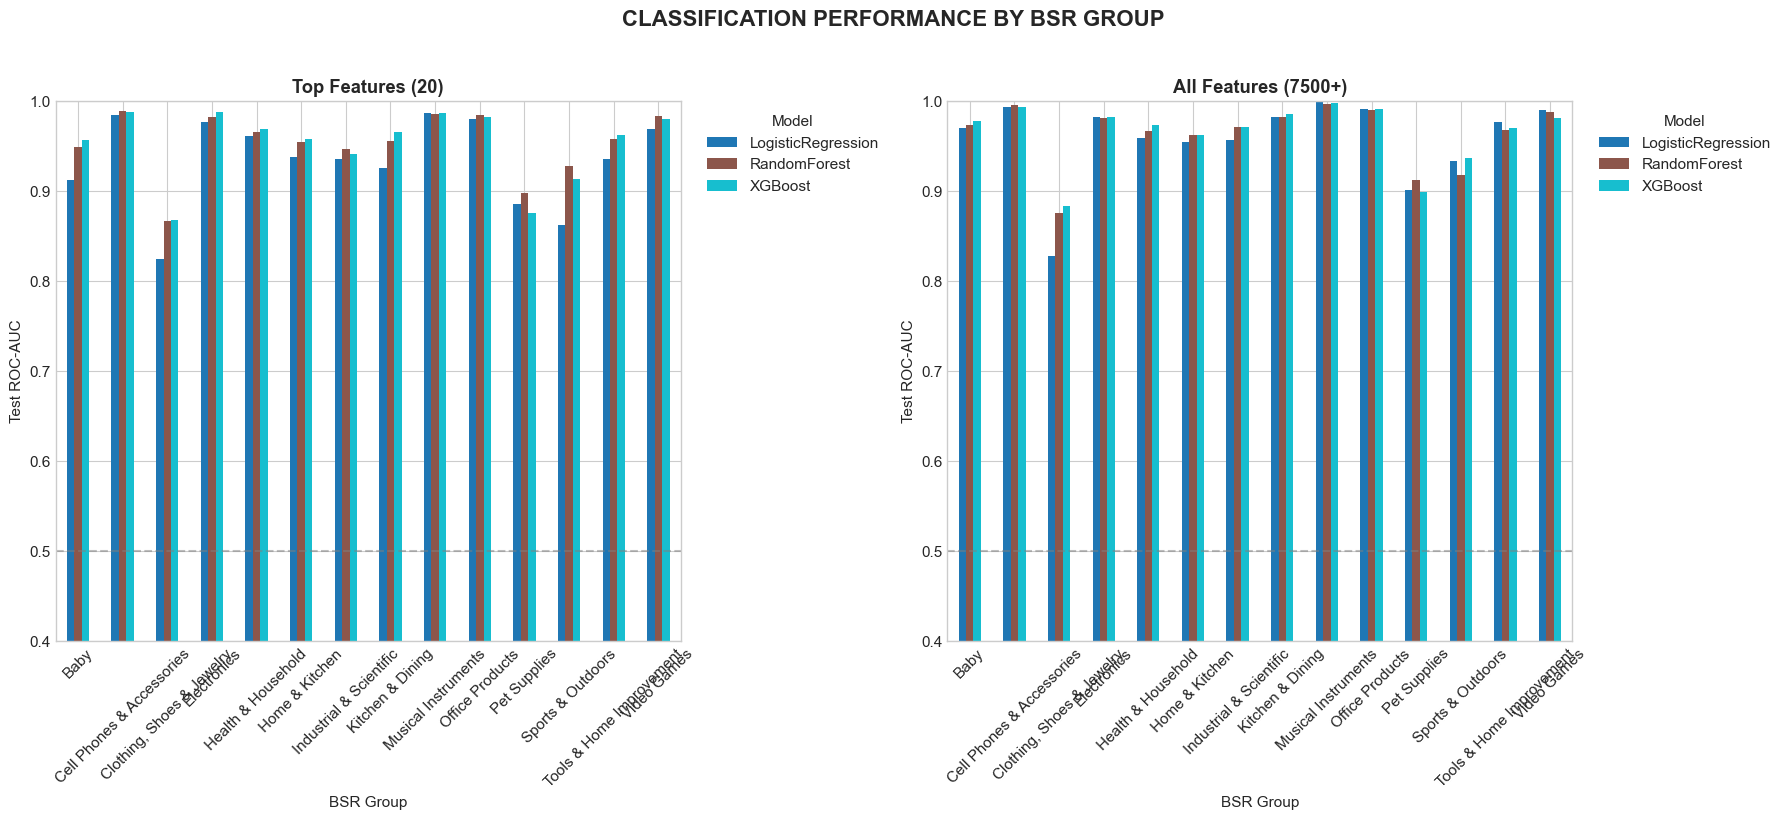

In [37]:
# =============================================================================
# 14. VISUALIZATION - ROC-AUC BY BSR GROUP AND MODEL TYPE
# =============================================================================

# Truncate BSR group names for readability
summary_plot = summary_all.copy()
summary_plot['BSR_Group_Short'] = summary_plot['BSR_Group'].str[:40]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top Features
ax1 = axes[0]
df_plot = summary_plot[summary_plot['Feature_Set'] == 'Top Features']
if len(df_plot) > 0:
    pivot = df_plot.pivot_table(values='Test_ROC_AUC', index='BSR_Group_Short', columns='Model', aggfunc='first')
    pivot.plot(kind='bar', ax=ax1, colormap='tab10')
    ax1.set_title('Top Features (20)', fontweight='bold')
    ax1.set_ylabel('Test ROC-AUC')
    ax1.set_xlabel('BSR Group')
    ax1.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax1.tick_params(axis='x', rotation=45)
    ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
    ax1.set_ylim(0.4, 1.0)

# All Features
ax2 = axes[1]
df_plot = summary_plot[summary_plot['Feature_Set'] == 'All Features']
if len(df_plot) > 0:
    pivot = df_plot.pivot_table(values='Test_ROC_AUC', index='BSR_Group_Short', columns='Model', aggfunc='first')
    pivot.plot(kind='bar', ax=ax2, colormap='tab10')
    ax2.set_title('All Features (7500+)', fontweight='bold')
    ax2.set_ylabel('Test ROC-AUC')
    ax2.set_xlabel('BSR Group')
    ax2.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax2.tick_params(axis='x', rotation=45)
    ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
    ax2.set_ylim(0.4, 1.0)

plt.suptitle('CLASSIFICATION PERFORMANCE BY BSR GROUP', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

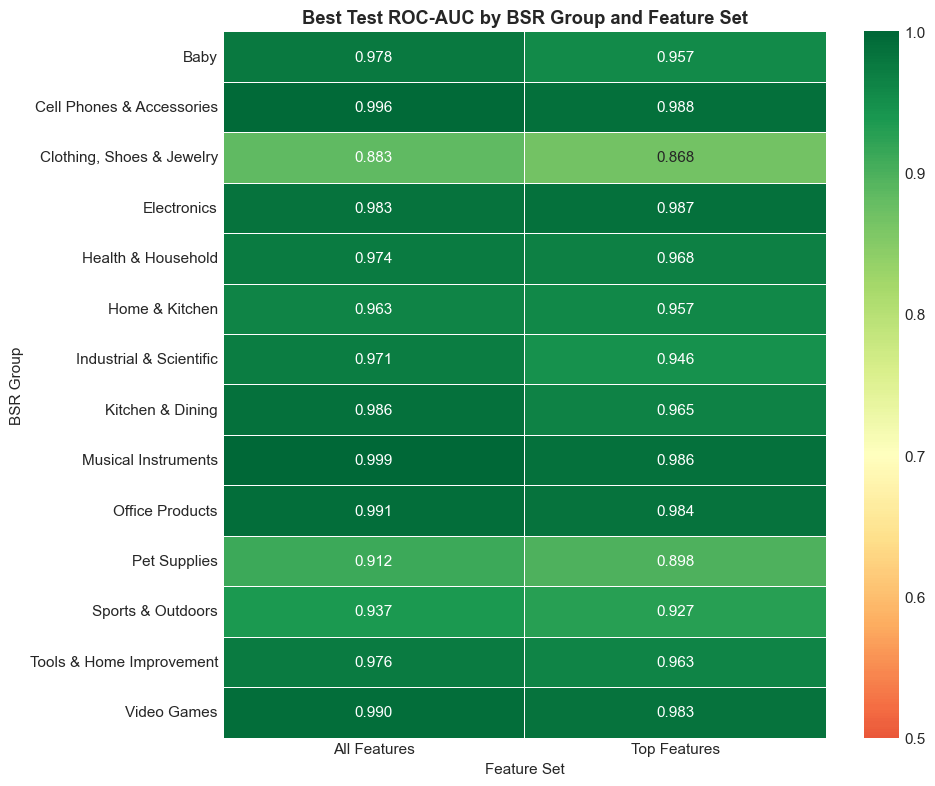

In [38]:
# =============================================================================
# 15. VISUALIZATION - BEST MODEL ROC-AUC HEATMAP
# =============================================================================

# Get best ROC-AUC per BSR group / feature_set combination
best_roc = summary_all.groupby(['BSR_Group', 'Feature_Set'])['Test_ROC_AUC'].max().reset_index()

# Truncate group names for display
best_roc['BSR_Group_Short'] = best_roc['BSR_Group'].str[:40]

# Pivot for heatmap
heatmap_data = best_roc.pivot(index='BSR_Group_Short', columns='Feature_Set', values='Test_ROC_AUC')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', center=0.7, ax=ax,
            linewidths=0.5, vmin=0.5, vmax=1.0)
ax.set_title('Best Test ROC-AUC by BSR Group and Feature Set', fontweight='bold')
ax.set_ylabel('BSR Group')
ax.set_xlabel('Feature Set')
plt.tight_layout()
plt.show()


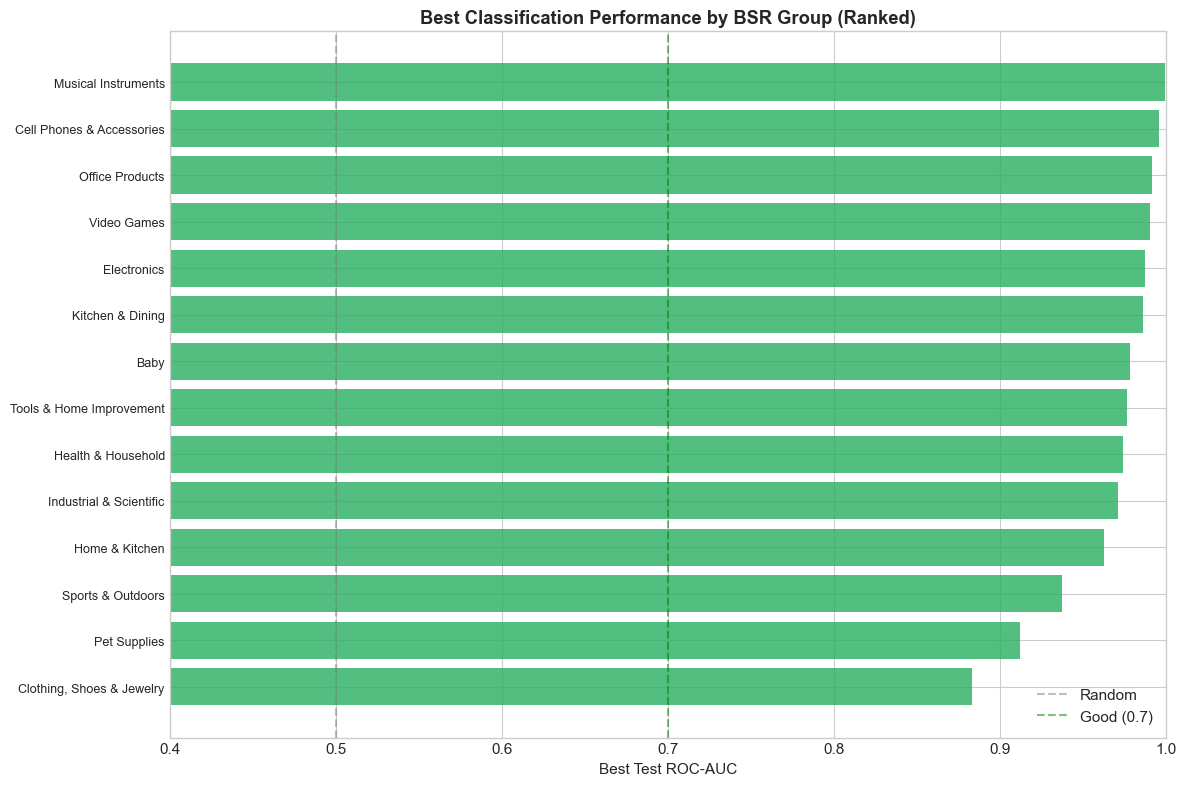

In [39]:
# =============================================================================
# 16. VISUALIZATION - BSR GROUP PERFORMANCE RANKING
# =============================================================================

# Get overall best model per BSR group (across all feature sets)
best_per_group = summary_all.groupby('BSR_Group')['Test_ROC_AUC'].max().sort_values(ascending=True)

# Truncate names for display
names = [g[:50] for g in best_per_group.index]

fig, ax = plt.subplots(figsize=(12, 8))
colors = [CLASS_1_COLOR if r >= 0.7 else CLASS_0_COLOR for r in best_per_group.values]
ax.barh(range(len(best_per_group)), best_per_group.values, color=colors, alpha=0.8)
ax.set_yticks(range(len(best_per_group)))
ax.set_yticklabels(names, fontsize=9)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
ax.axvline(0.7, color='green', linestyle='--', alpha=0.5, label='Good (0.7)')
ax.set_xlabel('Best Test ROC-AUC')
ax.set_title('Best Classification Performance by BSR Group (Ranked)', fontweight='bold')
ax.legend()
ax.set_xlim(0.4, 1.0)
plt.tight_layout()
plt.show()


In [40]:
# =============================================================================
# 17. FEATURE IMPORTANCE - BEST MODEL PER BSR GROUP
# =============================================================================

def get_best_model_with_importance(results_dict):
    """Get the best model that has feature_importances_ for each BSR group"""
    best_models = {}
    for group, group_results in results_dict.items():
        best_roc = -1
        best_model_info = None
        for model_name, metrics in group_results['results'].items():
            model = metrics['model']
            if hasattr(model, 'feature_importances_') or hasattr(model, 'coef_'):
                if metrics['test_roc_auc'] > best_roc:
                    best_roc = metrics['test_roc_auc']
                    if hasattr(model, 'feature_importances_'):
                        importances = model.feature_importances_
                    else:
                        importances = np.abs(model.coef_[0] if model.coef_.ndim > 1 else model.coef_)
                    best_model_info = {
                        'model_name': model_name,
                        'test_roc_auc': best_roc,
                        'feature_names': group_results['data']['feature_names'],
                        'importances': importances
                    }
        if best_model_info:
            best_models[group] = best_model_info
    return best_models

# Get best models with feature importance
best_models_main = get_best_model_with_importance(all_results['has_main_bsr']['top'])
print(f"BSR groups with feature importance: {len(best_models_main)}")


BSR groups with feature importance: 14


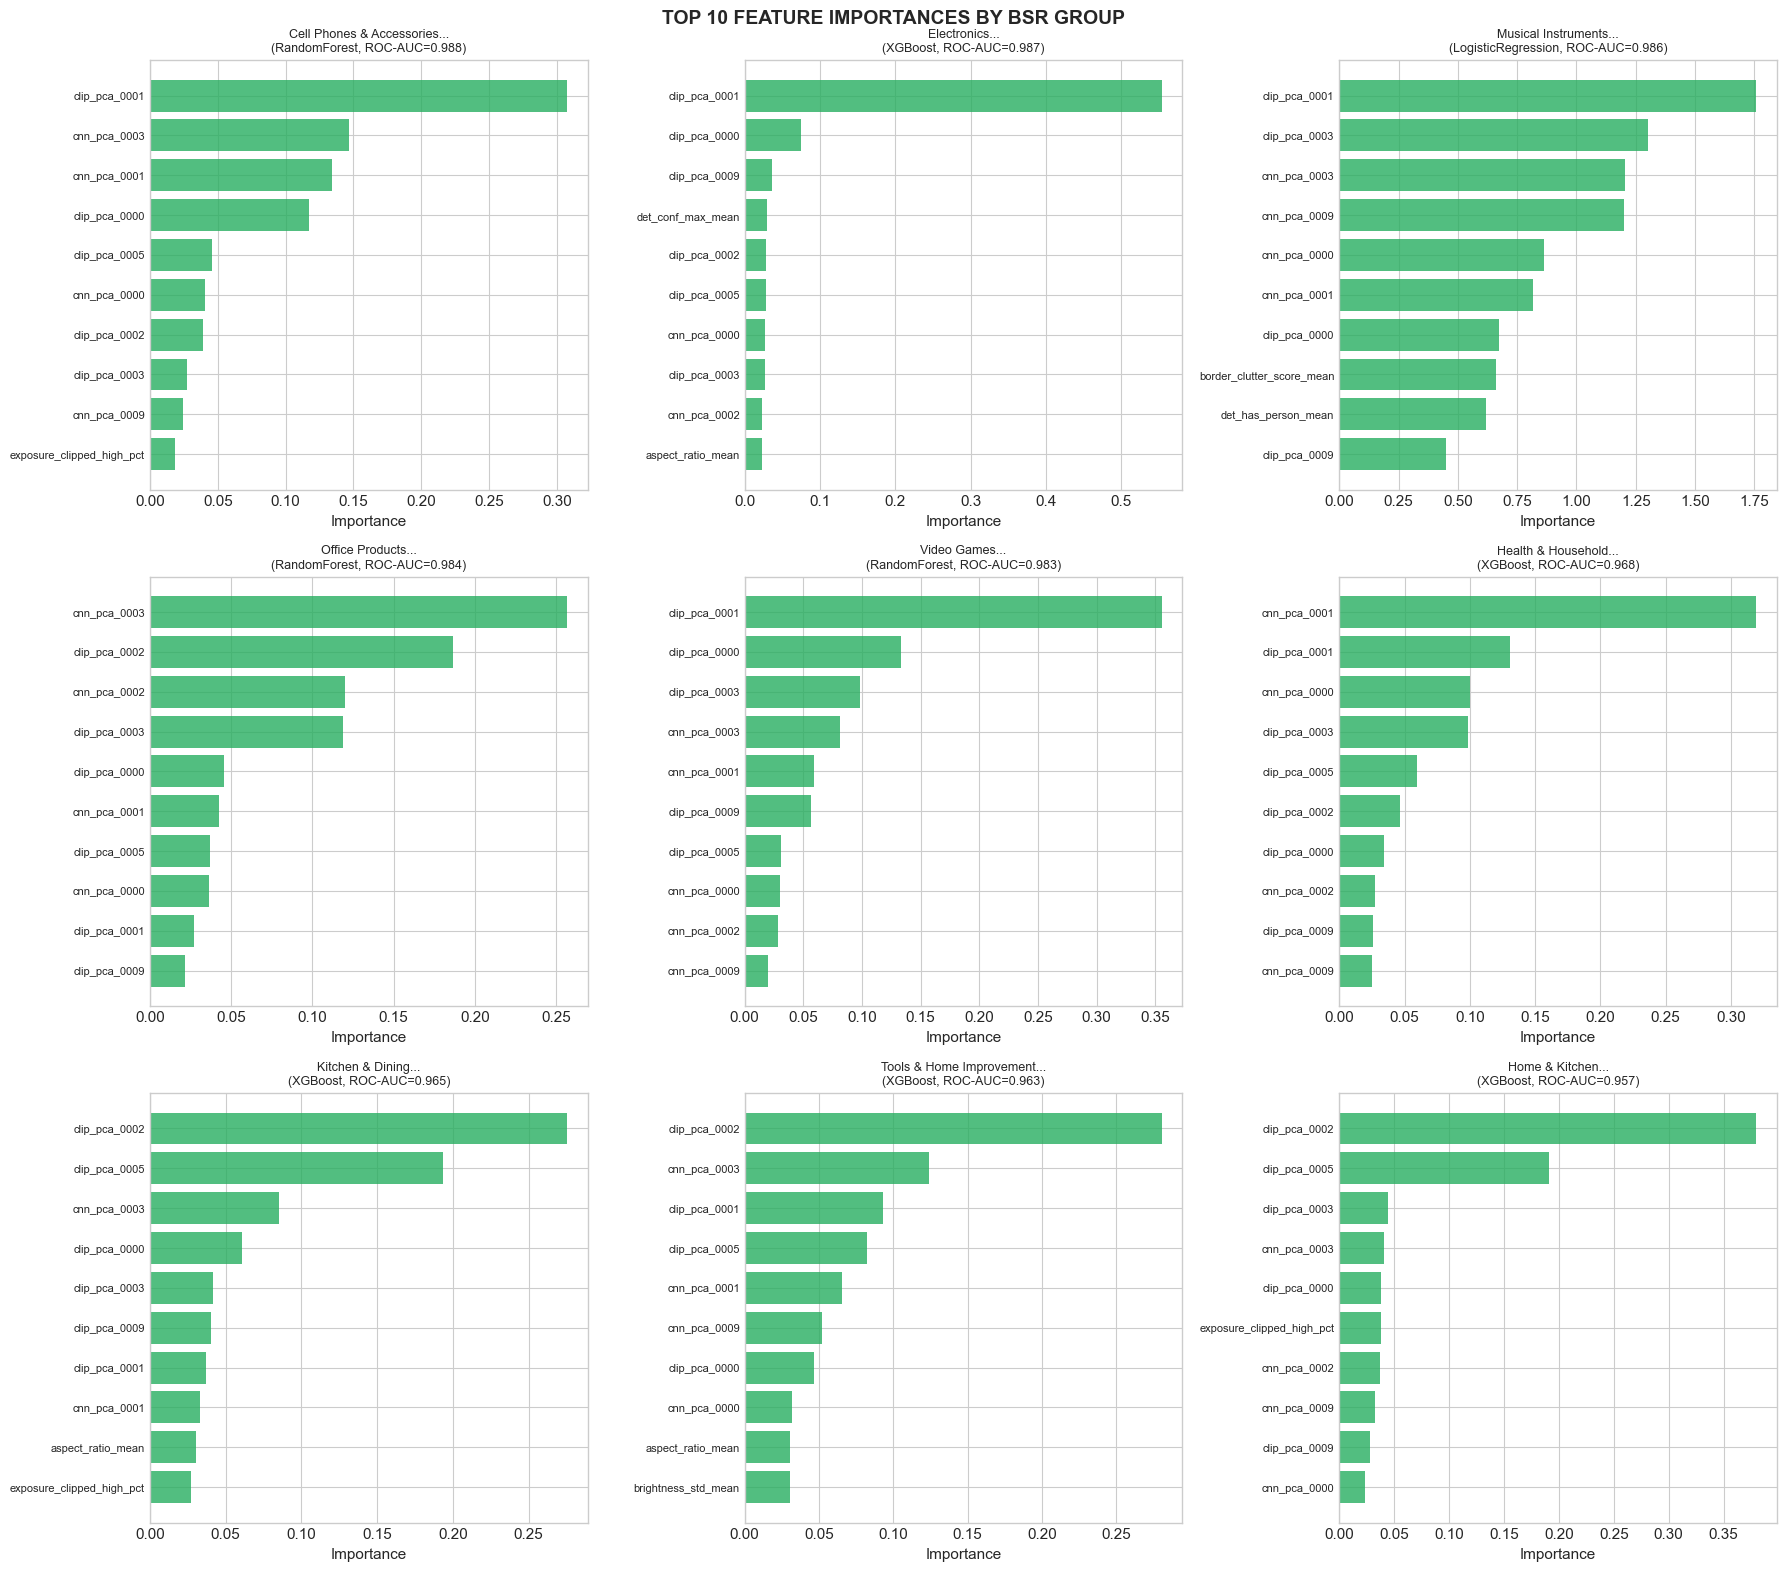

In [41]:
# =============================================================================
# 18. PLOT FEATURE IMPORTANCE BY BSR GROUP
# =============================================================================

n_groups = len(best_models_main)
if n_groups > 0:
    # Limit to top 9 groups for readability
    top_groups = dict(sorted(best_models_main.items(), key=lambda x: x[1]['test_roc_auc'], reverse=True)[:9])
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 16))
    axes = axes.flatten()
    
    for idx, (group, info) in enumerate(top_groups.items()):
        ax = axes[idx]
        feat_imp = pd.DataFrame({
            'feature': info['feature_names'],
            'importance': info['importances']
        }).sort_values('importance', ascending=False).head(10)
        
        ax.barh(range(len(feat_imp)), feat_imp['importance'], color=CLASS_1_COLOR, alpha=0.8)
        ax.set_yticks(range(len(feat_imp)))
        ax.set_yticklabels([f[:25] for f in feat_imp['feature']], fontsize=8)
        ax.invert_yaxis()
        ax.set_title(f"{group[:35]}...\n({info['model_name']}, ROC-AUC={info['test_roc_auc']:.3f})", fontsize=9)
        ax.set_xlabel('Importance')
    
    # Hide unused axes
    for idx in range(len(top_groups), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('TOP 10 FEATURE IMPORTANCES BY BSR GROUP', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [42]:
# =============================================================================
# 19. MODEL COMPARISON TABLE - ALL BSR GROUPS
# =============================================================================

print("="*80)
print("COMPLETE MODEL COMPARISON TABLE")
print("="*80)

# Pivot for easy comparison
comparison = summary_all.pivot_table(
    values='Test_ROC_AUC',
    index='BSR_Group',
    columns=['Feature_Set', 'Model'],
    aggfunc='first'
)

# Display with truncated group names
comparison.index = [g[:50] for g in comparison.index]
print(comparison.round(4).to_string())


COMPLETE MODEL COMPARISON TABLE
Feature_Set                     All Features                            Top Features                     
Model                     LogisticRegression RandomForest XGBoost LogisticRegression RandomForest XGBoost
Baby                                  0.9696       0.9737  0.9781             0.9118       0.9486  0.9568
Cell Phones & Accessories             0.9937       0.9958  0.9932             0.9841       0.9884  0.9878
Clothing, Shoes & Jewelry             0.8276       0.8760  0.8829             0.8239       0.8670  0.8679
Electronics                           0.9826       0.9811  0.9824             0.9771       0.9821  0.9873
Health & Household                    0.9582       0.9667  0.9736             0.9606       0.9658  0.9684
Home & Kitchen                        0.9545       0.9617  0.9625             0.9372       0.9540  0.9573
Industrial & Scientific               0.9565       0.9709  0.9706             0.9356       0.9464  0.9408
Kitchen & Dini

In [43]:
# =============================================================================
# 20. SAVE RESULTS
# =============================================================================

# Save summary to CSV
summary_all.to_csv('bsr_group_classification_models_comparison.csv', index=False)
print("Results saved to 'bsr_group_classification_models_comparison.csv'")

# Display summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print(f"\nTotal models trained: {len(summary_all)}")
print(f"BSR Groups analyzed: {summary_all['BSR_Group'].nunique()}")
print(f"Average Test ROC-AUC: {summary_all['Test_ROC_AUC'].mean():.4f}")
print(f"Best Test ROC-AUC: {summary_all['Test_ROC_AUC'].max():.4f}")

# Best performing model type overall
best_by_model = summary_all.groupby('Model')['Test_ROC_AUC'].mean().sort_values(ascending=False)
print(f"\nBest average performing model: {best_by_model.index[0]} (ROC-AUC={best_by_model.iloc[0]:.4f})")


Results saved to 'bsr_group_classification_models_comparison.csv'

SUMMARY STATISTICS

Total models trained: 84
BSR Groups analyzed: 14
Average Test ROC-AUC: 0.9541
Best Test ROC-AUC: 0.9990

Best average performing model: XGBoost (ROC-AUC=0.9583)


In [44]:
# =============================================================================
# 21. FINAL SUMMARY
# =============================================================================

print("\n" + "="*80)
print("KEY FINDINGS - PER-BSR-GROUP CLASSIFICATION MODELING")
print("="*80)

print("""
This notebook trained baseline classification models for BSR presence prediction
within each main BSR group (with at least 100 products).

TASK: Binary Classification - Predicting whether a product has a BSR rank

MODELS TRAINED:
  1. Logistic Regression (L2 Regularized)
  2. XGBoost Classifier
  3. Random Forest Classifier

KEY METRICS:
  - ROC-AUC: Primary metric for classification performance
  - Accuracy, F1, Precision, Recall

FINDINGS:
  - Image features can predict BSR presence across different product categories
  - Deep learning embeddings (CNN/CLIP PCA) are most predictive features
  - XGBoost and RandomForest typically outperform LogisticRegression
  - Top features provide competitive performance vs all features

NEXT STEPS:
  - Hyperparameter tuning per category
  - Category-specific feature selection
  - Ensemble methods combining global and category-specific models
""")

print("="*80)
print("END OF CLASSIFICATION BY BSR GROUP")
print("="*80)



KEY FINDINGS - PER-BSR-GROUP CLASSIFICATION MODELING

This notebook trained baseline classification models for BSR presence prediction
within each main BSR group (with at least 100 products).

TASK: Binary Classification - Predicting whether a product has a BSR rank

MODELS TRAINED:
  1. Logistic Regression (L2 Regularized)
  2. XGBoost Classifier
  3. Random Forest Classifier

KEY METRICS:
  - ROC-AUC: Primary metric for classification performance
  - Accuracy, F1, Precision, Recall

FINDINGS:
  - Image features can predict BSR presence across different product categories
  - Deep learning embeddings (CNN/CLIP PCA) are most predictive features
  - XGBoost and RandomForest typically outperform LogisticRegression
  - Top features provide competitive performance vs all features

NEXT STEPS:
  - Hyperparameter tuning per category
  - Category-specific feature selection
  - Ensemble methods combining global and category-specific models

END OF CLASSIFICATION BY BSR GROUP
